In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import datetime as dt
import scipy.stats as stats
from scipy.stats import poisson
import math as m

# pd.set_option('display.max_rows', None)

# importing the datafiles
maq_data = 'Marylebone_AirQualityDataHourly_2018-2021_clean.csv'
maq_df = pd.read_csv(maq_data, skiprows=[0, 1], na_values=['No data'], header=2)
raq_data = 'Rochester_AirQualityDataHourly_2018-2021_clean.csv'
raq_df = pd.read_csv(raq_data, skiprows=[0, 1], na_values=['No data'], header=2)

# average pm10 emissions of two datafiles
maq_pm10_avg = maq_df['PM10 particulate matter (Hourly measured)'].mean()
raq_pm10_avg = raq_df['PM10 particulate matter (Hourly measured)'].mean()

# converting the 'Data Time' column in both frames to a pandas 'datatime' object
maq_df['Date Time'] = pd.to_datetime(maq_df['Date Time'])
raq_df['Date Time'] = pd.to_datetime(raq_df['Date Time'])

# calculating the average monthly pm10 emissions for both datafiles
maq_monthly_avg = maq_df.resample('M', on='Date Time')['PM10 particulate matter (Hourly measured)'].mean()
raq_monthly_avg = raq_df.resample('M', on='Date Time')['PM10 particulate matter (Hourly measured)'].mean()

# calculating the average monthly difference between 2018 and 2021 for each data frame
maq_monthly_avg_diff = maq_monthly_avg.diff().mean()
raq_monthly_avg_diff = raq_monthly_avg.diff().mean()

# printing out the results
print("Marylebone PM10 particulate matter (Hourly measured) average:", maq_pm10_avg)
print("Rochester PM10 particulate matter (Hourly measured) average:", raq_pm10_avg)
print("Marylebone PM10 particulate matter (Hourly measured) average monthly difference from 2018-2021:", maq_monthly_avg_diff)
print("Rochester PM10 particulate matter (Hourly measured) average monthly difference from 2018-2021:", raq_monthly_avg_diff)

Marylebone PM10 particulate matter (Hourly measured) average: 20.93622107554624
Rochester PM10 particulate matter (Hourly measured) average: 15.664442436607404
Marylebone PM10 particulate matter (Hourly measured) average monthly difference from 2018-2021: -0.2566319236773346
Rochester PM10 particulate matter (Hourly measured) average monthly difference from 2018-2021: 0.024168717910722247


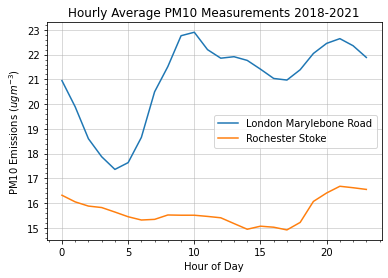

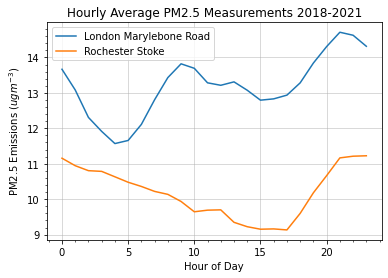

In [3]:
# grouping the data by hour of day and calculating the mean pm10 and pm2.5 emissions
maq_hourly_avg_pm10 = maq_df.groupby(maq_df['Date Time'].dt.hour)['PM10 particulate matter (Hourly measured)'].mean()
raq_hourly_avg_pm10 = raq_df.groupby(raq_df['Date Time'].dt.hour)['PM10 particulate matter (Hourly measured)'].mean()
maq_hourly_avg_pm2 = maq_df.groupby(maq_df['Date Time'].dt.hour)['PM2.5 particulate matter (Hourly measured)'].mean()
raq_hourly_avg_pm2 = raq_df.groupby(raq_df['Date Time'].dt.hour)['PM2.5 particulate matter (Hourly measured)'].mean()

# ploting hourly average pm10 and pm2.5 emissions against hour of day
plt.plot(maq_hourly_avg_pm10, label='London Marylebone Road')
plt.plot(raq_hourly_avg_pm10, label='Rochester Stoke')
plt.xlabel('Hour of Day')
plt.ylabel('PM10 Emissions ($ugm^{-3}$)')
plt.title('Hourly Average PM10 Measurements 2018-2021')
plt.legend()
plt.grid(alpha=0.6)
plt.minorticks_on()
plt.show()

plt.plot(maq_hourly_avg_pm2, label='London Marylebone Road')
plt.plot(raq_hourly_avg_pm2, label='Rochester Stoke')
plt.xlabel('Hour of Day')
plt.ylabel('PM2.5 Emissions ($ugm^{-3}$)')
plt.title('Hourly Average PM2.5 Measurements 2018-2021')
plt.grid(alpha=0.6)
plt.minorticks_on()
plt.legend()
plt.show()

In [8]:
# adding 'Hour' column
maq_df['Hour'] = maq_df['Date Time'].dt.hour
raq_df['Hour'] = raq_df['Date Time'].dt.hour

# Group by hour of the day and calculate the mean PM10 particulate matter
maq_hourly_avg = maq_df.groupby('Hour')['PM10 particulate matter (Hourly measured)'].mean()
raq_hourly_avg = raq_df.groupby('Hour')['PM10 particulate matter (Hourly measured)'].mean()

# Calculate the differences between each consecutive hour
maq_hourly_diff = maq_hourly_avg.diff()
raq_hourly_diff = raq_hourly_avg.diff()

hourly_avg_df = pd.DataFrame({
    'Hour': maq_hourly_avg.index,
    'London Marylebone Rd.': maq_hourly_avg.values,
    'Rochester Stoke': raq_hourly_avg.values
})

hourly_avg_df.set_index('Hour', inplace=True)
hourly_avg_df.columns = pd.MultiIndex.from_tuples([('Average PM10 emissions ($ugm^{-3}$)', 'London Marylebone Rd.'), ('Average PM10 emissions ($ugm^{-3}$)', 'Rochester Stoke')])
hourly_avg_df.name = 'Hourly average emissions of PM10 particulate matter'
caption = 'Hourly average PM10 particulate matter measurements'
hourly_avg_df = hourly_avg_df.style.set_caption(caption)

hourly_avg_df

In [4]:
# importing heathrow weather data
heathrow_weather_data = 'Weather_data_hourly_Heathrow-Airport.csv'
hwd_df = pd.read_csv(heathrow_weather_data, na_values=['No data'])

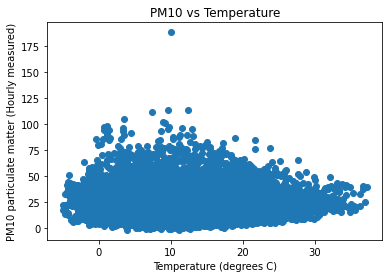

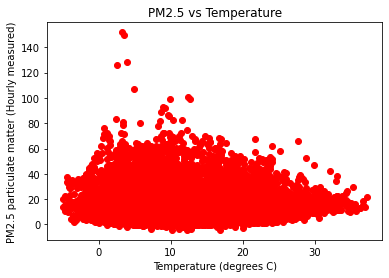

In [5]:
# starting from 2018-01-01 00:00:00 to match maq_df and resetting the index
hwd_df_new = hwd_df.loc[hwd_df['Date_Hour'] >= '2018-01-01 00:00:00']
hwd_df_new = hwd_df_new.reset_index(drop=True)

# Sort hwd_df_new by temperature
hwd_df_sorted = hwd_df_new.sort_values(by='Temperature (degrees C)')

# Align the indexes of hwd_df_sorted and maq_df
hwd_df_sorted = hwd_df_sorted.loc[maq_df.index]

# create a scatter plot of pm2.5 vs temperature and the poisson dist.
plt.scatter(hwd_df_sorted['Temperature (degrees C)'], maq_df['PM10 particulate matter (Hourly measured)'])
plt.title('PM10 vs Temperature')
plt.xlabel('Temperature (degrees C)')
plt.ylabel('PM10 particulate matter (Hourly measured)')
plt.show()


# create a scatter plot of pm2.5 vs temperature and the poisson dist.
plt.scatter(hwd_df_sorted['Temperature (degrees C)'], maq_df['PM2.5 particulate matter (Hourly measured)'], color = 'red')
plt.title('PM2.5 vs Temperature')
plt.xlabel('Temperature (degrees C)')
plt.ylabel('PM2.5 particulate matter (Hourly measured)')
plt.show()

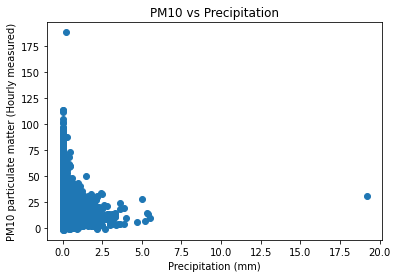

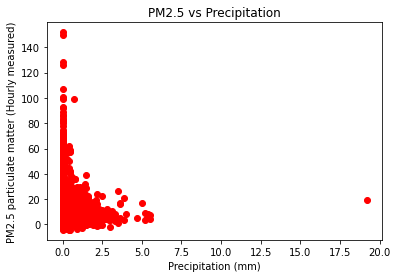

In [6]:
# create a scatter plot of pm10 vs precipitation and the poisson dist.
plt.scatter(hwd_df_sorted['Precipitation (mm)'], maq_df['PM10 particulate matter (Hourly measured)'])
plt.title('PM10 vs Precipitation')
plt.xlabel('Precipitation (mm)')
plt.ylabel('PM10 particulate matter (Hourly measured)')
plt.show()


# create a scatter plot of pm2.5 vs precipitation and the poisson dist.
plt.scatter(hwd_df_sorted['Precipitation (mm)'], maq_df['PM2.5 particulate matter (Hourly measured)'], color = 'red')
plt.title('PM2.5 vs Precipitation')
plt.xlabel('Precipitation (mm)')
plt.ylabel('PM2.5 particulate matter (Hourly measured)')
plt.show()

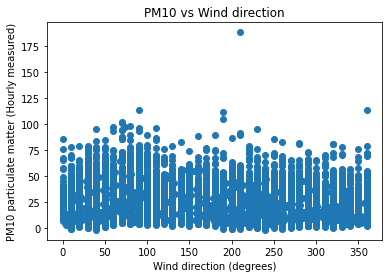

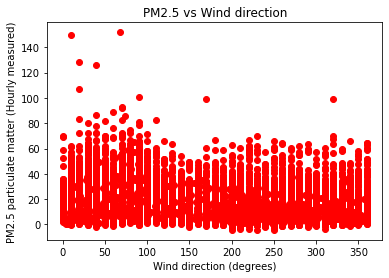

In [7]:
# create a scatter plot of pm10 vs wind direction
plt.scatter(hwd_df_sorted['Wind direction (degrees)'], maq_df['PM10 particulate matter (Hourly measured)'])
plt.title('PM10 vs Wind direction')
plt.xlabel('Wind direction (degrees)')
plt.ylabel('PM10 particulate matter (Hourly measured)')
plt.show()


# create a scatter plot of pm2.5 vs wind direction
plt.scatter(hwd_df_sorted['Wind direction (degrees)'], maq_df['PM2.5 particulate matter (Hourly measured)'], color = 'red')
plt.title('PM2.5 vs Wind direction')
plt.xlabel('Wind direction (degrees)')
plt.ylabel('PM2.5 particulate matter (Hourly measured)')
plt.show()

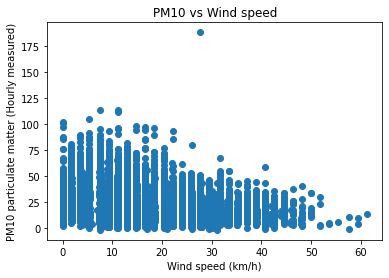

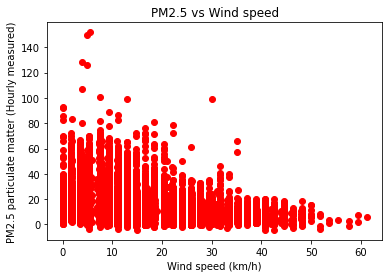

In [8]:
# create a scatter plot of pm10 vs wind speed
plt.scatter(hwd_df_sorted['Wind speed (km/h)'], maq_df['PM10 particulate matter (Hourly measured)'])
plt.title('PM10 vs Wind speed')
plt.xlabel('Wind speed (km/h)')
plt.ylabel('PM10 particulate matter (Hourly measured)')
plt.show()


# create a scatter plot of pm2.5 vs wind speed
plt.scatter(hwd_df_sorted['Wind speed (km/h)'], maq_df['PM2.5 particulate matter (Hourly measured)'], color = 'red')
plt.title('PM2.5 vs Wind speed')
plt.xlabel('Wind speed (km/h)')
plt.ylabel('PM2.5 particulate matter (Hourly measured)')
plt.show()

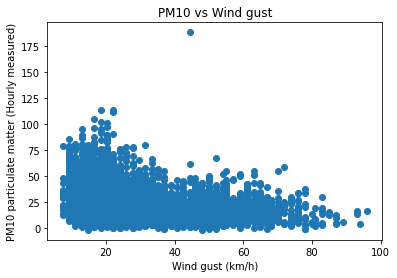

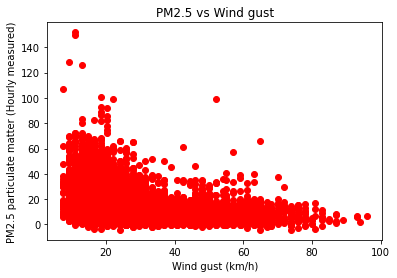

In [9]:
# create a scatter plot of pm10 vs wind gust
plt.scatter(hwd_df_sorted['Wind gust (km/h)'], maq_df['PM10 particulate matter (Hourly measured)'])
plt.title('PM10 vs Wind gust')
plt.xlabel('Wind gust (km/h)')
plt.ylabel('PM10 particulate matter (Hourly measured)')
plt.show()


# create a scatter plot of pm2.5 vs wind gust
plt.scatter(hwd_df_sorted['Wind gust (km/h)'], maq_df['PM2.5 particulate matter (Hourly measured)'], color = 'red')
plt.title('PM2.5 vs Wind gust')
plt.xlabel('Wind gust (km/h)')
plt.ylabel('PM2.5 particulate matter (Hourly measured)')
plt.show()

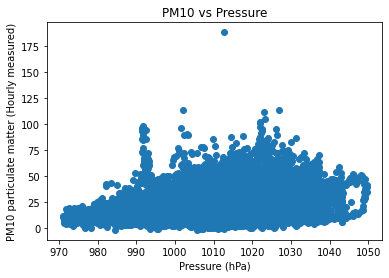

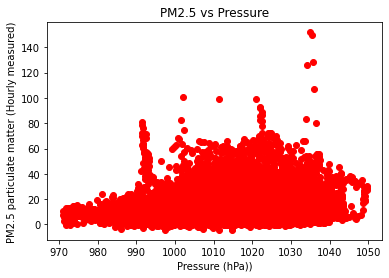

In [10]:
# create a scatter plot of pm10 vs pressure
plt.scatter(hwd_df_sorted['Pressure (hPa)'], maq_df['PM10 particulate matter (Hourly measured)'])
plt.title('PM10 vs Pressure')
plt.xlabel('Pressure (hPa)')
plt.ylabel('PM10 particulate matter (Hourly measured)')
plt.show()


# create a scatter plot of pm2.5 vs pressure
plt.scatter(hwd_df_sorted['Pressure (hPa)'], maq_df['PM2.5 particulate matter (Hourly measured)'], color = 'red')
plt.title('PM2.5 vs Pressure')
plt.xlabel('Pressure (hPa))')
plt.ylabel('PM2.5 particulate matter (Hourly measured)')
plt.show()